**Data cleaning Start**

In [1]:
import re
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir
for _ in range(6):
    if (project_root / 'requirements.txt').exists(): break
    project_root = project_root.parent

sys.path.insert(0, str(project_root / 'src'))
from data_ai.config import DATA_RAW_DIR, DATA_PROCESSED_DIR, ensure_directories
ensure_directories()

print('Project root:', project_root)
print('Raw data dir:', DATA_RAW_DIR)
print('Processed dir:', DATA_PROCESSED_DIR)

Project root: /Users/user/Documents/Ucll/3rd Yr/Integration Project/Data-AI-T1-
Raw data dir: /Users/user/Documents/Ucll/3rd Yr/Integration Project/Data-AI-T1-/data/raw
Processed dir: /Users/user/Documents/Ucll/3rd Yr/Integration Project/Data-AI-T1-/data/processed


**Loading the data**

In [2]:
RAW_CSV = DATA_RAW_DIR / 'CarData.csv'

#handles commas inside the JSON blob
_LINE_PATTERN = re.compile(r'^(\d+),(\d+),"(.+)",(\w+),([\d\- :\.]+)$')

def fix_json(raw: str) -> dict:
    """Strips the PostgreSQL CSV quote"""
    return json.loads(raw.replace("'\"", '"'))

rows = []
with open(RAW_CSV) as f:
    for line in f.read().splitlines():
        m = _LINE_PATTERN.match(line)
        if not m: continue
        row_id, car_id, json_raw, event, ts = m.groups()
        data = fix_json(json_raw)
        rows.append({'id': int(row_id), 'car_id': int(car_id),
                      'event': event, 'timestamp': ts, **data})

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
df.head()

Loaded 735 rows, 9 columns


,id,car_id,event,timestamp,hit,speed,isMoving,hitStrength,orientation
0,1,2,speed,2026-05-20 09:51:18.856883,False,stopped,False,none,unknown
1,2,2,speed,2026-05-20 09:51:19.154162,False,stopped,False,none,unknown
2,3,2,speed,2026-05-20 09:51:19.159086,False,stopped,False,none,unknown
3,4,2,speed,2026-05-20 09:51:19.163053,False,stopped,False,none,unknown
4,5,2,orientation,2026-05-20 09:51:19.302691,False,unknown,False,none,upright


**Explore the data**

 ** dis is for the dtypes **
id                      int64
car_id                  int64
event                  object
timestamp      datetime64[ns]
hit                      bool
speed                  object
isMoving                 bool
hitStrength            object
orientation            object
dtype: object

 ** value counts **
car_id         : {2: np.int64(735)}
event          : {'speed': np.int64(659), 'hit': np.int64(28), 'orientation': np.int64(16), 'move': np.int64(16), 'stop': np.int64(16)}
speed          : {'stopped': np.int64(647), 'unknown': np.int64(60), 'fast': np.int64(16), 'slow': np.int64(8), 'medium': np.int64(4)}
hitStrength    : {'none': np.int64(707), 'light': np.int64(28)}
orientation    : {'unknown': np.int64(719), 'upright': np.int64(12), 'tipped': np.int64(4)}

hit = True:      28 rows (3.8%)
isMoving = True: 72 rows (9.8%)
Time range: 2026-05-20 09:51:18.856883 → 2026-05-20 09:53:00.694739
Session duration: 101s


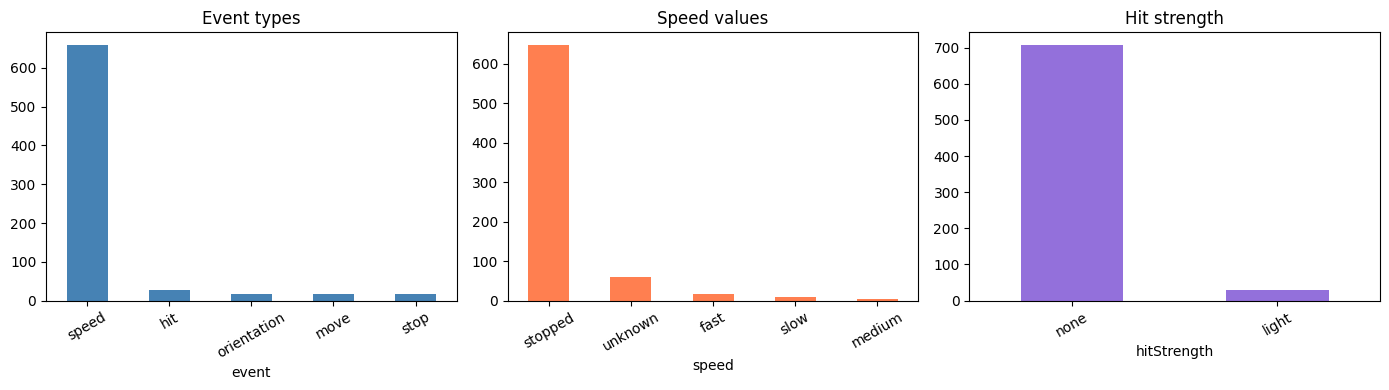

In [4]:
print(' ** dis is for the dtypes **')
print(df.dtypes)
print()
print(' ** value counts **')
for col in ['car_id','event','speed','hitStrength','orientation']:
    print(f'{col:15}: {dict(df[col].value_counts())}')
print()
print(f'hit = True:      {df["hit"].sum()} rows ({df["hit"].mean()*100:.1f}%)')
print(f'isMoving = True: {df["isMoving"].sum()} rows ({df["isMoving"].mean()*100:.1f}%)')
print(f'Time range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Session duration: {(df["timestamp"].max() - df["timestamp"].min()).seconds}s')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['event'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Event types')
df['speed'].value_counts().plot(kind='bar', ax=axes[1], color='coral', title='Speed values')
df['hitStrength'].value_counts().plot(kind='bar', ax=axes[2], color='mediumpurple', title='Hit strength')
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(DATA_RAW_DIR.parent.parent / 'artifacts' / 'reports' / 'raw_distributions.png', dpi=120)
plt.show()

**Clean & transform**

In [5]:
df_clean = df.copy()

#Replace 'unknown' with NaN
df_clean['speed'] = df_clean['speed'].replace('unknown', np.nan)
df_clean['orientation'] = df_clean['orientation'].replace('unknown', np.nan)

# encodings
SPEED_ORDER    = {'stopped': 0, 'slow': 1, 'medium': 2, 'fast': 3}
HIT_STR_ORDER  = {'none': 0, 'light': 1, 'medium': 2, 'heavy': 3}
ORIENT_ORDER   = {'upright': 0, 'tipped': 1, 'flipped': 2}
EVENT_ORDER    = {'stop': 0, 'speed': 1, 'move': 2, 'orientation': 3, 'hit': 4}

df_clean['speed_enc']       = df_clean['speed'].map(SPEED_ORDER)
df_clean['hitStrength_enc'] = df_clean['hitStrength'].map(HIT_STR_ORDER)
df_clean['orientation_enc'] = df_clean['orientation'].map(ORIENT_ORDER)
df_clean['event_enc']       = df_clean['event'].map(EVENT_ORDER)

# dis for changin the boolean to int
df_clean['hit_int']      = df_clean['hit'].astype(int)
df_clean['isMoving_int'] = df_clean['isMoving'].astype(int)

# this'd only counts when the car is actually hit
df_clean['damage_score'] = df_clean['hitStrength_enc'] * df_clean['hit_int']

print('Null counts after encoding:')
print(df_clean[['speed_enc','hitStrength_enc','orientation_enc','event_enc']].isnull().sum())
df_clean.head()

Null counts after encoding:
speed_enc           60
hitStrength_enc      0
orientation_enc    719
event_enc            0
dtype: int64


,id,car_id,event,timestamp,hit,speed,isMoving,hitStrength,orientation,speed_enc,hitStrength_enc,orientation_enc,event_enc,hit_int,isMoving_int,damage_score
0,1,2,speed,2026-05-20 09:51:18.856883,False,stopped,False,none,NaN,0.0,0,NaN,1,0,0,0
1,2,2,speed,2026-05-20 09:51:19.154162,False,stopped,False,none,NaN,0.0,0,NaN,1,0,0,0
2,3,2,speed,2026-05-20 09:51:19.159086,False,stopped,False,none,NaN,0.0,0,NaN,1,0,0,0
3,4,2,speed,2026-05-20 09:51:19.163053,False,stopped,False,none,NaN,0.0,0,NaN,1,0,0,0
4,5,2,orientation,2026-05-20 09:51:19.302691,False,NaN,False,none,upright,NaN,0,0.0,3,0,0,0


**Feature engineer**

In [ ]:
#Time since session / the match start (seconds)
t0 = df_clean['timestamp'].min()
df_clean['t_sec'] = (df_clean['timestamp'] - t0).dt.total_seconds()

df_clean['roll_hit_rate']    = df_clean['hit_int'].rolling(10, min_periods=1).mean()
df_clean['roll_moving_rate'] = df_clean['isMoving_int'].rolling(10, min_periods=1).mean()
df_clean['roll_damage']      = df_clean['damage_score'].rolling(10, min_periods=1).sum()
df_clean['window_10s'] = (df_clean['t_sec'] // 10).astype(int)

print(f'Feature columns added. Final shape: {df_clean.shape}')
df_clean[['t_sec','roll_hit_rate','roll_moving_rate','roll_damage','window_10s']].describe()

Feature columns added. Final shape: (735, 21)


,t_sec,roll_hit_rate,roll_moving_rate,roll_damage,window_10s
count,735.000000,735.000000,735.000000,735.000000,735.000000
mean,50.679667,0.038095,0.097959,0.380952,4.590476
std,29.605397,0.121038,0.258920,1.210385,2.959245
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.153801,0.000000,0.000000,0.000000,2.000000
50%,49.195510,0.000000,0.000000,0.000000,4.000000
75%,75.605463,0.000000,0.000000,0.000000,7.000000
max,101.837856,0.600000,1.000000,6.000000,10.000000


**Winner /damage analysis** (uhmm Note : we need both data from both cars 🥀)

Damage per 10s window (car 2):
    car_id  window_10s  total_damage  hit_count  avg_speed  moving_rate
0        2           0             0          0   0.060606     0.108108
1        2           1             0          0   0.070175     0.131148
2        2           2             0          0   0.000000     0.000000
3        2           3             0          0   0.000000     0.000000
4        2           4             0          0   0.000000     0.000000
5        2           5            28         28   1.333333     0.666667
6        2           6             0          0   0.115942     0.103896
7        2           7             0          0   0.000000     0.000000
8        2           8             0          0   0.000000     0.000000
9        2           9             0          0   0.000000     0.000000
10       2          10             0          0   0.000000     0.000000

Car 2 session summary:
  Total hits:        28
  Total damage score: 28
  Hit rate:          3.8%


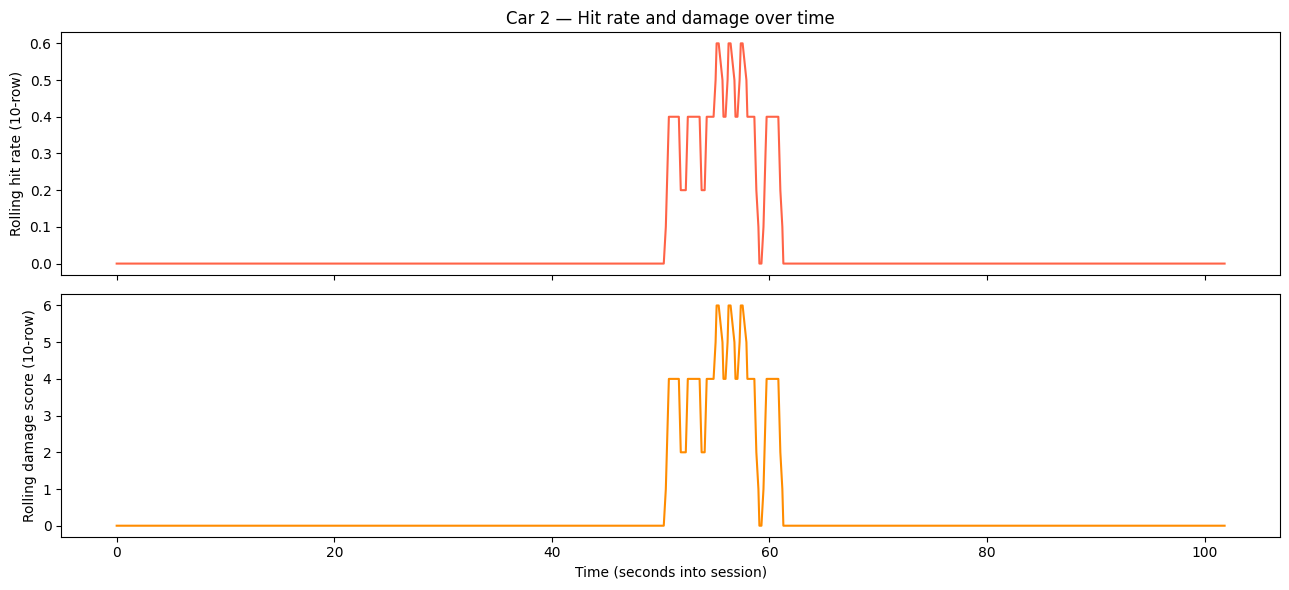

In [7]:
# Aggregate damage per car per 10s window
window_dmg = (
    df_clean.groupby(['car_id', 'window_10s'])
    .agg(total_damage=('damage_score', 'sum'),
         hit_count=('hit_int', 'sum'),
         avg_speed=('speed_enc', 'mean'),
         moving_rate=('isMoving_int', 'mean'))
    .reset_index()
)

print('Damage per 10s window (car 2):')
print(window_dmg.to_string())

total_damage = df_clean['damage_score'].sum()
total_hits   = df_clean['hit_int'].sum()
print(f'\nCar 2 session summary:')
print(f'  Total hits:        {total_hits}')
print(f'  Total damage score: {total_damage}')
print(f'  Hit rate:          {total_hits/len(df_clean)*100:.1f}%')

# Plot damage over time
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df_clean['t_sec'], df_clean['roll_hit_rate'], color='tomato', linewidth=1.5)
axes[0].set_ylabel('Rolling hit rate (10-row)')
axes[0].set_title('Car 2 — Hit rate and damage over time')

axes[1].plot(df_clean['t_sec'], df_clean['roll_damage'], color='darkorange', linewidth=1.5)
axes[1].set_ylabel('Rolling damage score (10-row)')
axes[1].set_xlabel('Time (seconds into session)')

plt.tight_layout()
plt.savefig(DATA_RAW_DIR.parent.parent / 'artifacts' / 'reports' / 'damage_over_time.png', dpi=120)
plt.show()

**Saveing the cleaned data**

In [8]:
OUTPUT_FILE = DATA_PROCESSED_DIR / 'cleaned_car_data.csv'
df_clean.to_csv(OUTPUT_FILE, index=False)
print(f'Saved {len(df_clean)} rows → {OUTPUT_FILE}')
print(f'Columns: {list(df_clean.columns)}')

Saved 735 rows → /Users/user/Documents/Ucll/3rd Yr/Integration Project/Data-AI-T1-/data/processed/cleaned_car_data.csv
Columns: ['id', 'car_id', 'event', 'timestamp', 'hit', 'speed', 'isMoving', 'hitStrength', 'orientation', 'speed_enc', 'hitStrength_enc', 'orientation_enc', 'event_enc', 'hit_int', 'isMoving_int', 'damage_score', 't_sec', 'roll_hit_rate', 'roll_moving_rate', 'roll_damage', 'window_10s']
